In [2]:
# Import Libraries
import os
import glob
from collections import Counter
import joblib

import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

from skimage.feature import hog
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
# Data Path
IMG_SIZE = 128
DATA_PATH = "../Data/Scores"  

In [4]:
# Load dataset
paths, labels = [], []
for shape_name in sorted(os.listdir(DATA_PATH)):
    shape_path = os.path.join(DATA_PATH, shape_name)
    if not os.path.isdir(shape_path):
        continue
    for score in sorted(os.listdir(shape_path)):
        score_path = os.path.join(shape_path, score)
        if not os.path.isdir(score_path):
            continue
        label = f"{shape_name}_{score}"
        for ext in ("*.png", "*.jpg", "*.jpeg"):
            for p in glob.glob(os.path.join(score_path, ext)):
                paths.append(p)
                labels.append(label)

df = pd.DataFrame({"path": paths, "label": labels})
print("[INFO] Total images:", len(df))

[INFO] Total images: 4297


In [5]:
# Class distribution
counts = Counter(df['label'])
print("[INFO] Example class distribution:", list(counts.items())[:8])

[INFO] Example class distribution: [('Circle_0', 5), ('Circle_2', 1), ('Circle_3', 112), ('Circle_4', 457), ('Diagonal_0', 4), ('Diagonal_3', 2), ('Diagonal_4', 70), ('Diagonal_5', 479)]


In [6]:
# Feature extraction (HOG + Hu Moments + Area)
def extract_features(path, img_size=IMG_SIZE):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (img_size, img_size))
    
    # HOG features
    hog_feats = hog(img, orientations=9, pixels_per_cell=(8,8),
                    cells_per_block=(2,2), block_norm='L2-Hys', feature_vector=True)
    # Hu moments
    moments = cv2.moments(img)
    hu_feats = cv2.HuMoments(moments).flatten()
    # Area
    area = [np.sum(img) / 255.0]
    
    return np.hstack([hog_feats, hu_feats, area])

print("[INFO] Extracting features (please wait)...")
features = []
for p in tqdm(df['path'], desc="Extracting"):
    features.append(extract_features(p))
X = np.vstack(features)
y_labels = np.array(df['label'])
print("[INFO] Feature matrix shape:", X.shape)

[INFO] Extracting features (please wait)...


Extracting: 100%|██████████| 4297/4297 [00:49<00:00, 86.85it/s]


[INFO] Feature matrix shape: (4297, 8108)


In [1]:
# Label encoding
le = LabelEncoder()
y = le.fit_transform(y_labels)
print("[INFO] Total classes:", len(le.classes_))

NameError: name 'LabelEncoder' is not defined

In [8]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print("[INFO] Train size:", X_train.shape[0], "Test size:", X_test.shape[0])

[INFO] Train size: 3437 Test size: 860


In [9]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
# Train Gradient Boosting
gb_clf = GradientBoostingClassifier(
    n_estimators=200,  
    learning_rate=0.1, 
    max_depth=3,       
    random_state=42
)
print("[INFO] Training Gradient Boosting...")
gb_clf.fit(X_train_scaled, y_train)

[INFO] Training Gradient Boosting...


GradientBoostingClassifier(n_estimators=200, random_state=42)

In [29]:
# Evaluation
y_pred = gb_clf.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
print(f"\nGradient Boosting Test Accuracy: {acc:.4f}")

present_labels = np.unique(y_test)
target_names = [le.classes_[i] for i in present_labels]

report_dict = classification_report(
    y_test, y_pred,
    labels=present_labels,
    target_names=target_names,
    output_dict=True,
    zero_division=0
)
print(classification_report(
    y_test, y_pred,
    labels=np.unique(y_test),
    target_names=le.classes_[np.unique(y_test)]
))


Gradient Boosting Test Accuracy: 0.6500
                      precision    recall  f1-score   support

            Circle_3       0.17      0.04      0.06        26
            Circle_4       0.72      0.94      0.82       100
          Diagonal_0       0.00      0.00      0.00         1
          Diagonal_4       0.17      0.13      0.15        15
          Diagonal_5       0.82      0.79      0.81       100
 Overlapped circle_0       0.00      0.00      0.00         1
 Overlapped circle_5       0.36      0.15      0.21        34
 Overlapped circle_6       0.71      0.76      0.73        85
Overlapped pencils_0       0.00      0.00      0.00         2
Overlapped pencils_3       0.00      0.00      0.00         1
Overlapped pencils_4       0.00      0.00      0.00         6
Overlapped pencils_5       0.33      0.23      0.27        31
Overlapped pencils_6       0.52      0.60      0.56        43
            Square_4       0.00      0.00      0.00         9
            Square_5       0

/home/mahabur-alam/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/mahabur-alam/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/mahabur-alam/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(resu

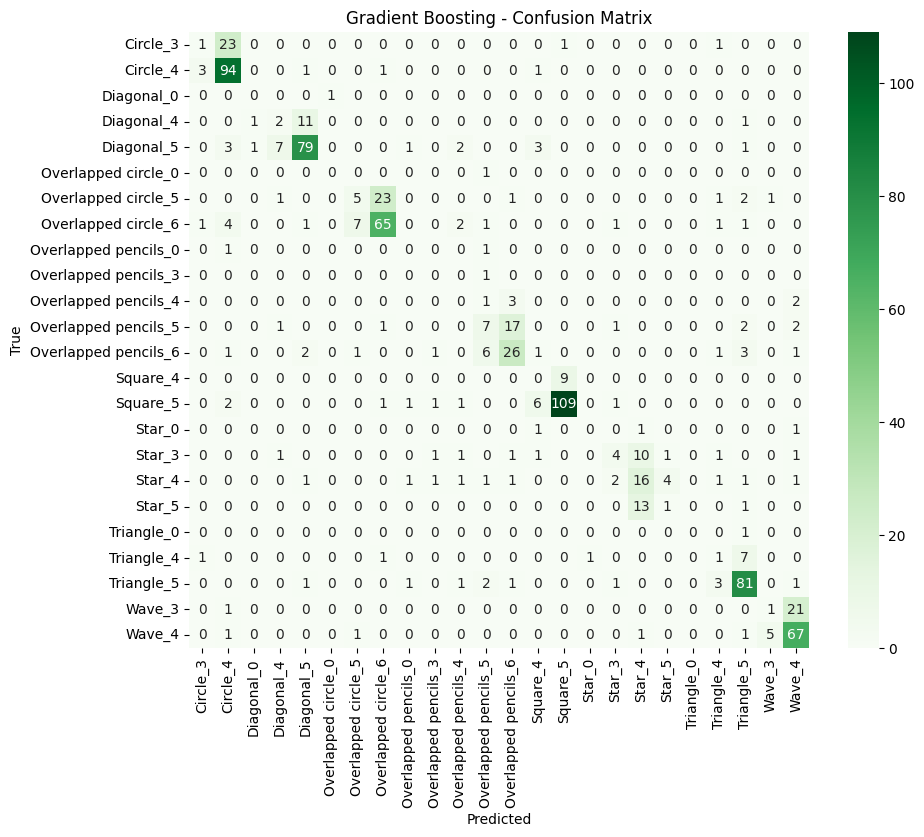

In [20]:
# Confusion Matrix Show
cm = confusion_matrix(y_test, y_pred, labels=present_labels)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Gradient Boosting - Confusion Matrix")
#plt.legend()
plt.show()

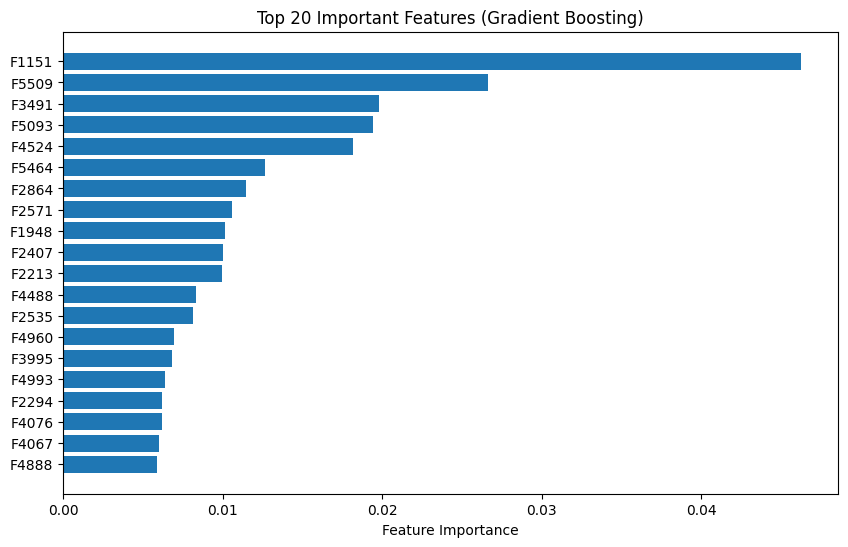

In [22]:
# Feature Importance Chart
importances = gb_clf.feature_importances_
indices = np.argsort(importances)[-20:]  # top 20 features
plt.figure(figsize=(10,6))
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [f"F{i}" for i in indices])
plt.xlabel("Feature Importance")
plt.title("Top 20 Important Features (Gradient Boosting)")
#plt.legend()
plt.show()

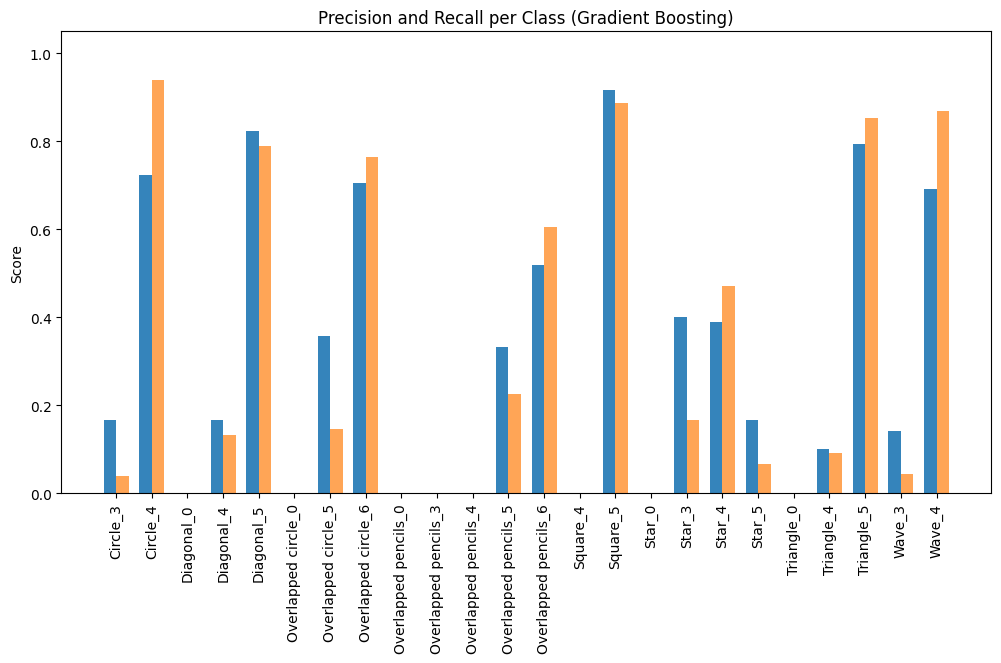

In [23]:
# Precision & Recall per Class
class_rows = report_df.loc[target_names]
plt.figure(figsize=(12,6))
x = np.arange(len(class_rows))
width = 0.35
plt.bar(x - width/2, class_rows['precision'], width, label='Precision', alpha=0.9)
plt.bar(x + width/2, class_rows['recall'], width, label='Recall', alpha=0.7)
plt.xticks(x, class_rows.index, rotation=90)
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.title("Precision and Recall per Class (Gradient Boosting)")
#plt.legend()
plt.show()

In [16]:
# Save Model
SAVE_DIR = "./model_outputs/Gradient Boosting(GB)"
os.makedirs(SAVE_DIR, exist_ok=True)

In [31]:
# Save model
model_path = os.path.join(SAVE_DIR, "gb_model.pkl")
joblib.dump(gb_clf, model_path)
print(f"[SAVED] GB model → {model_path}")

[SAVED] GB model → ./model_outputs/Gradient Boosting(GB)/gb_model.pkl


In [30]:
# Save Classification report
report_csv_path = os.path.join(SAVE_DIR, "GB_classification_report.csv")
report_df.to_csv(report_csv_path)
print(f"[SAVED] Report (csv) → {report_csv_path}")

[SAVED] Report (csv) → ./model_outputs/Gradient Boosting(GB)/GB_classification_report.csv


In [36]:
# Confusion Matrix Show
cm = confusion_matrix(y_test, y_pred, labels=present_labels)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Gradient Boosting - Confusion Matrix")
plt.tight_layout()
cm_path = os.path.join(SAVE_DIR, "confusion_matrix.png")
plt.savefig(cm_path, dpi=150)
plt.close()
print(f"[SAVED] Confusion Matrix → {cm_path}")

[SAVED] Confusion Matrix → ./model_outputs/Gradient Boosting(GB)/confusion_matrix.png


In [33]:
# Feature Importance Chart
importances = gb_clf.feature_importances_
indices = np.argsort(importances)[-20:]  # top 20 features
plt.figure(figsize=(10,6))
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [f"F{i}" for i in indices])
plt.xlabel("Feature Importance")
plt.title("Top 20 Important Features (Gradient Boosting)")
plt.tight_layout()
feat_path = os.path.join(SAVE_DIR, "feature_importance.png")
plt.savefig(feat_path, dpi=150)
plt.close()
print(f"[SAVED] Feature Importance Chart → {feat_path}")

[SAVED] Feature Importance Chart → ./model_outputs/Gradient Boosting(GB)/feature_importance.png


In [34]:
# Precision & Recall per Class
class_rows = report_df.loc[target_names]
plt.figure(figsize=(12,6))
x = np.arange(len(class_rows))
width = 0.35
plt.bar(x - width/2, class_rows['precision'], width, label='Precision', alpha=0.9)
plt.bar(x + width/2, class_rows['recall'], width, label='Recall', alpha=0.7)
plt.xticks(x, class_rows.index, rotation=90)
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.title("Precision and Recall per Class (Gradient Boosting)")
plt.legend()
plt.tight_layout()
pr_path = os.path.join(SAVE_DIR, "precision_recall_per_class.png")
plt.savefig(pr_path, dpi=150)
plt.close()
print(f"[SAVED] Precision/Recall Chart → {pr_path}")

[SAVED] Precision/Recall Chart → ./model_outputs/Gradient Boosting(GB)/precision_recall_per_class.png
